# FAST AEP USING FLOWERS

FLOWERS is an AEP model which efficiently computes a wind farm's AEP. It uses numerous simplifications and assumptions, but most importantly a Fourier transform turning discrete components, functions of wind direction, into a continuous function. From this, it  solves the integral analytically, rather than   numerically, also enabling the computation of analytical gradients.

Here a step by step guide to all of its functionalities, consisting of the computation of wind farm AEP , gradients, specific turbine AEP and plotting. 

### Package imports

Import NO Jensen and Gaussian Bastankhah FLOWERS models.

In [2]:
from FLOWERS import NOJ_flowers, gaussian_flowers

Other imports needed

In [3]:
from py_wake.examples.data.hornsrev1 import Hornsrev1Site, V80
import time

# Ignore numerical errors coming from FLOWERS (division by zero, etc.)
import warnings
warnings.filterwarnings("ignore")

c:\Users\s232514\AppData\Local\anaconda3\envs\tests\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Initialize AEP conditions

In [4]:
site = Hornsrev1Site()
turbine = V80()
x, y = site.initial_position.T

# Wake expansion coefficients
k_NOJ = 0.04
k_gaussian = 0.03

### Create wind farm models
The number of Fourier terms (`n_terms`) determines the accuracy of the model, as well as the computational time. A value of `n_terms = 10` is recommened by the original paper as the balance between the two. The maximum number of Fourier modes is given by the number of wind directions in the windrose, and is obtained as `N_wd//2 + 1`. HornsrevSite has 12 wind direction bins, so in this case, the maximum number is 7.

In [5]:
# NO Jensen wake model
wfm_NOJ = NOJ_flowers(site = site,
                      WindTurbine = turbine,
                      k = k_NOJ,
                      n_terms = 7)

# Gaussian wake model
wfm_gaussian = gaussian_flowers(site = site,
                               WindTurbine = turbine,
                               k = k_gaussian,
                               n_terms = 7)

### Compute wind farm AEP
The wind farm AEP is computed for a set of x and y coordinates defining the wind turbine positions, by means of the `aep` function. NOJ FLOWERS has been found to underestimate AEP, while Gaussian is known to overestimate it. FLOWERS is not meant to compute AEP accurately, but to reflect the windfarm's dynamics for layout optimization purposes.

In [6]:
AEP_NOJ = wfm_NOJ.aep(x, y)

print(f"AEP NOJ: {AEP_NOJ:.2f} GWh")

AEP_gaussian = wfm_gaussian.aep(x, y)

print(f"AEP Gaussian: {AEP_gaussian:.2f} GWh")

AEP NOJ: 539.52 GWh
AEP Gaussian: 783.08 GWh


### Compute gradients
Given that the AEP is computed solving the AEP integral anallytically rather than numerically, it enables the derivation of analytical gradients. Nevertheless, these are only available for NO Jensen. 

The package can derive the gradients using automatic differentiation with the Autograd package (https://github.com/HIPS/autograd) for both FLOWERS model, and for the case of NOJ FLOWERS, they can be obtained analytically. 

Gradients are obtained by means of the `aep_gradient` function, using `gradient_method="Exact"` for analytical gradients (NOJ only) and `gradient_method="Autograd"` for automatic differentiation. It can be chosen whether the user wants to return the function computing the gradients, where the `x` and `y` inputs are left as `None`, or the gradients evaluated at certain coordinates, by providing the specific coordinates. Moreover, the package supports derivation with respect to x (`wrt_arg=["x"]`), y (`wrt_arg=["y"]`) or both (`wrt_arg=["x","y"]`).



#### Using automatic differentiation

In [7]:
# With respect to x and y - Evaluating the gradient
# NO Jensen
daep_dx_NOJ, daep_dy_NOJ = wfm_NOJ.aep_gradient(gradient_method="Autograd", wrt_arg=["x","y"], x=x, y=y)
# Gaussian Bastankhah
daep_dx_gaussian, daep_dy_gaussian = wfm_gaussian.aep_gradient(gradient_method="Autograd", wrt_arg=["x","y"], x=x, y=y)

# With respect to x only - Evaluating the gradient
# NO Jensen
daep_dx_NOJ = wfm_NOJ.aep_gradient(gradient_method="Autograd", wrt_arg=["x"], x=x, y=y)
# Gaussian Bastankhah
daep_dx_gaussian = wfm_gaussian.aep_gradient(gradient_method="Autograd", wrt_arg=["x"], x=x, y=y)

# With respect to y only - Returning the gradient function
# NO Jensen
daep_dy_NOJ_func = wfm_NOJ.aep_gradient(gradient_method="Autograd", wrt_arg=["y"])
daep_dy_NOJ = daep_dy_NOJ_func(x, y)

# Gaussian Bastankhah
daep_dy_gaussian_func = wfm_gaussian.aep_gradient(gradient_method="Autograd", wrt_arg=["y"])
daep_dy_gaussian = daep_dy_gaussian_func(x, y)

#### Using analytical gradients (NO Jensen only)

In [8]:
# With respect to x and y - Evaluating the gradient
daep_dx_NOJ, daep_dy_NOJ = wfm_NOJ.aep_gradient(gradient_method="Exact", wrt_arg=["x","y"], x=x, y=y)

# With respect to x only - Evaluating the gradient
daep_dx_NOJ = wfm_NOJ.aep_gradient(gradient_method="Exact", wrt_arg=["x"], x=x, y=y)

# With respect to y only - Returning the gradient function
daep_dy_NOJ_func = wfm_NOJ.aep_gradient(gradient_method="Exact", wrt_arg=["y"])
daep_dy_NOJ = daep_dy_NOJ_func(x, y)

#### Gradient methods comparison
Both Automatic and analytical differentiation are faster than other gradient computation methods such as finite differences. However there are slight numerical differences between the two.

In [9]:
# Gradient for NOJ using analytical gradients
time_i = time.time()
daep_dx_exact, daep_dy_exact = wfm_NOJ.aep_gradient(gradient_method="Exact", wrt_arg=["x","y"], x=x, y=y)
time_f = time.time()
print(f"Time taken for exact gradient: {time_f - time_i:.4f} seconds")

# Gradient for NOJ using autograd
time_i = time.time()
daep_dx_auto, daep_dy_auto = wfm_NOJ.aep_gradient(gradient_method="Autograd", wrt_arg=["x","y"], x=x, y=y)
time_f = time.time()
print(f"Time taken for autograd gradient: {time_f - time_i:.4f} seconds")

print("\nComparing gradients for NOJ model:")
print("Gradient (Exact) - daep_dx:", daep_dx_exact[:5])
print("Gradient (Exact) - daep_dy:", daep_dy_exact[:5])
print("Gradient (Autograd) - daep_dx:", daep_dx_auto[:5])
print("Gradient (Autograd) - daep_dy:", daep_dy_auto[:5])

Time taken for exact gradient: 0.0178 seconds
Time taken for autograd gradient: 0.0167 seconds

Comparing gradients for NOJ model:
Gradient (Exact) - daep_dx: [-0.00272678 -0.00297185 -0.00308627 -0.0031235  -0.00309369]
Gradient (Exact) - daep_dy: [ 2.47404164e-03  8.22434197e-04  2.42093316e-04 -7.74882171e-05
 -3.29068183e-04]
Gradient (Autograd) - daep_dx: [-0.00272952 -0.00297314 -0.00308732 -0.00312445 -0.00309452]
Gradient (Autograd) - daep_dy: [ 2.47518454e-03  8.24315479e-04  2.44086694e-04 -7.54416638e-05
 -3.26954582e-04]


### AEP for a specific turbine
FLOWERS supports the calculation of the AEP for a specific wind turbine from the wind farm, using the `aep_i` function.

(It should be checked how useful this is, especially for Gaussian)

In [10]:
turbine_number = 63

# NO Jensen AEP for turbine 63
aep_63_NOJ = wfm_NOJ.aep_i(x, y)[turbine_number]
print(f"AEP for turbine {turbine_number} using NOJ: {aep_63_NOJ:.2f} GWh")

# Gaussian Bastankhah AEP for turbine 63
aep_63_gaussian = wfm_gaussian.aep_i(x, y)[turbine_number]
print(f"AEP for turbine {turbine_number} using Gaussian: {aep_63_gaussian:.2f} GWh")

AEP for turbine 63 using NOJ: 7.48 GWh
AEP for turbine 63 using Gaussian: 9.79 GWh


#### Plotting AEP for each turbine

It is possible to plot the wind farm and the AEP coming from each turbine using the `plot_AEP_per_turbine` function.

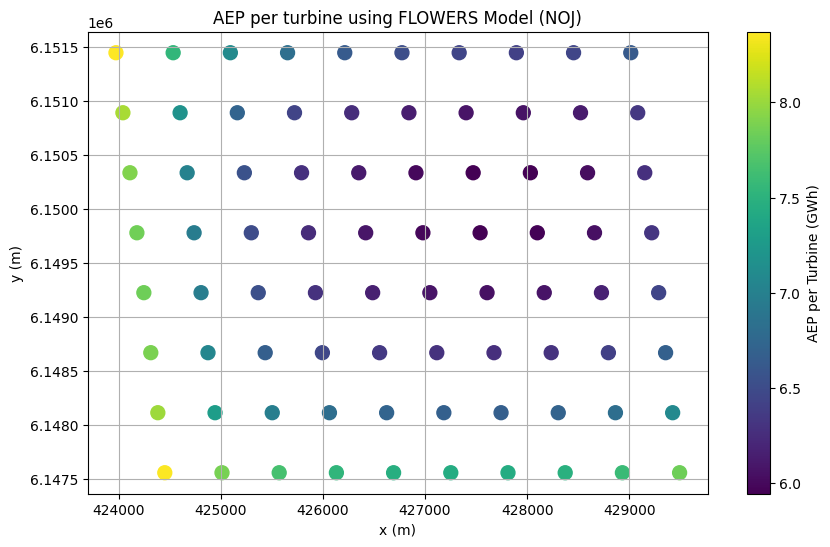

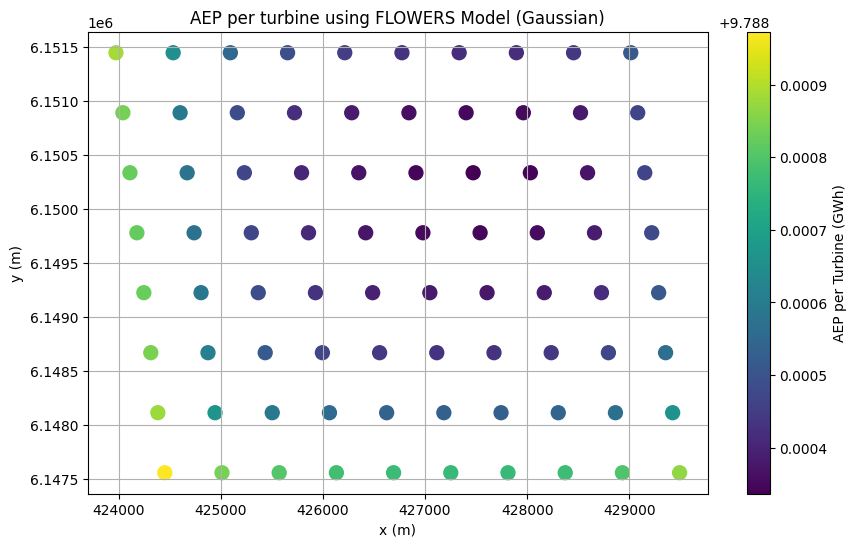

In [11]:
# Plotting AEP per turbine for NOJ model
wfm_NOJ.plot_AEP_per_turbine(x, y)

# Plotting AEP per turbine for Gaussian model
wfm_gaussian.plot_AEP_per_turbine(x, y)